<a href="https://colab.research.google.com/github/Sarthakgupta05/AI_Based_Inventory_Management/blob/main/AI_Based_Inventory_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importing the dependecies

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 2.Data Loading and Understanding

In [ ]:
url = "https://drive.google.com/uc?id=1bBtYUvo19Wf48qWqX4iVj-wdyapBPWF7"
df = pd.read_csv(url)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [ ]:
df.shape

(73100, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

#3. Data Preprocessing

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

# Extract the year and add it as a new column
df['Year'] = df['Date'].dt.year

# Display the updated DataFrame
print(df.head())

        Date Store ID Product ID     Category Region  Inventory Level  \
0 2022-01-01     S001      P0001    Groceries  North              231   
1 2022-01-01     S001      P0002         Toys  South              204   
2 2022-01-01     S001      P0003         Toys   West              102   
3 2022-01-01     S001      P0004         Toys  North              469   
4 2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  Year  
0             Rainy                  0               29.69      Autumn  2022  
1     

In [ ]:
df.describe()


,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing,Year
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077,2022.502052
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000,2022.000000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000,2022.000000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000,2023.000000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000,2023.000000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000,2024.000000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408,0.502728


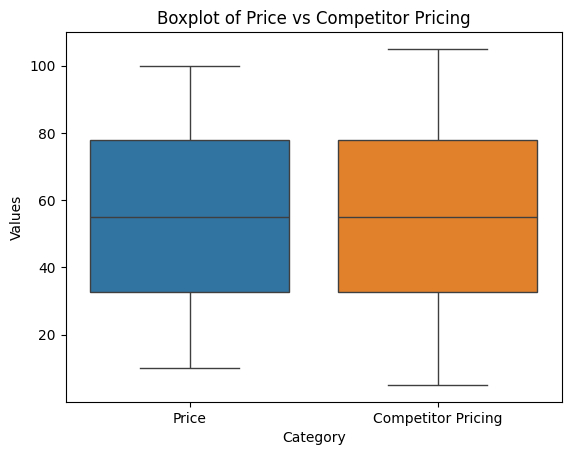

In [ ]:
sns.boxplot(data=df[["Price", "Competitor Pricing"]])

plt.xlabel("Category")
plt.ylabel("Values")
plt.title("Boxplot of Price vs Competitor Pricing")

plt.show()

            Units Sold
Date                  
2022-01-01       14484
2022-01-02       13415
2022-01-03       13681
2022-01-04       14084
2022-01-05       12572


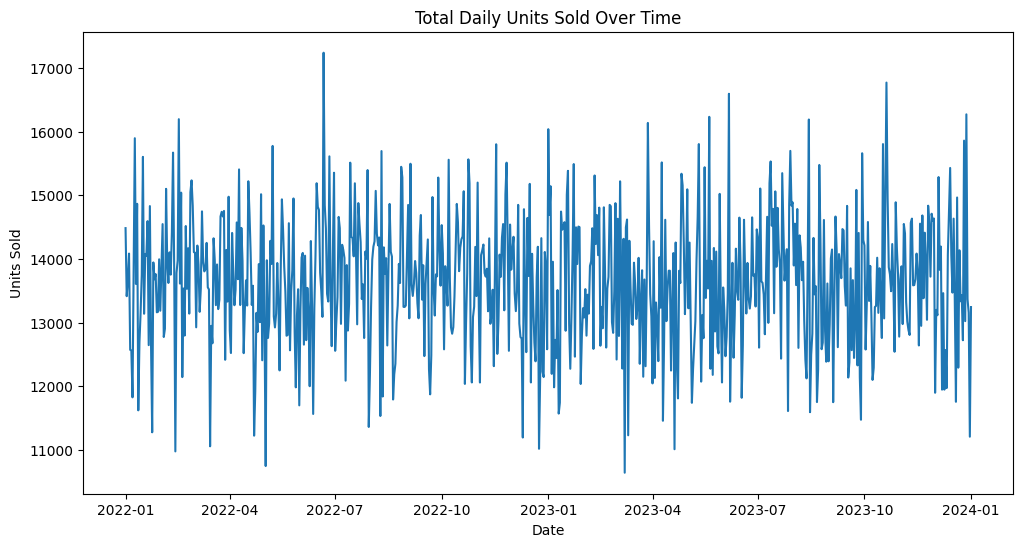

In [ ]:
ts_data = df.groupby('Date')['Units Sold'].sum().reset_index()

ts_data['Date'] = pd.to_datetime(ts_data['Date'])

ts_data = ts_data.set_index('Date')

ts_data = ts_data.asfreq('D')

ts_data = ts_data.fillna(0)

print(ts_data.head())

plt.figure(figsize=(12, 6))
plt.plot(ts_data['Units Sold'])
plt.title('Total Daily Units Sold Over Time')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Conclusion: Data Stationary hai (d=0 use kar sakte hain, lekin d=1 safe rehta hai).")
    else:
        print("Conclusion: Data Non-Stationary hai (Humein d=1 ya d=2 use karna padega).")

adf_test(ts_data['Units Sold'])

ADF Statistic: -26.379506701264116
p-value: 0.0
Conclusion: Data Stationary hai (d=0 use kar sakte hain, lekin d=1 safe rehta hai).


#ARIMA Model (Training)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

train_size = int(len(ts_data) - 30)
train, test = ts_data.iloc[:train_size], ts_data.iloc[train_size:]

print(f"Training Data Size: {len(train)}")
print(f"Testing Data Size: {len(test)}")

model = ARIMA(train['Units Sold'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

Training Data Size: 701
Testing Data Size: 30
                               SARIMAX Results                                
Dep. Variable:             Units Sold   No. Observations:                  701
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5903.490
Date:                Wed, 01 Apr 2026   AIC                          11818.981
Time:                        13:45:13   BIC                          11846.287
Sample:                    01-01-2022   HQIC                         11829.536
                         - 12-02-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7853      0.034    -22.790      0.000      -0.853      -0.718
ar.L2         -0.6492      0.044    -14.685      0.000      -0.736      -0.563
ar.L3 

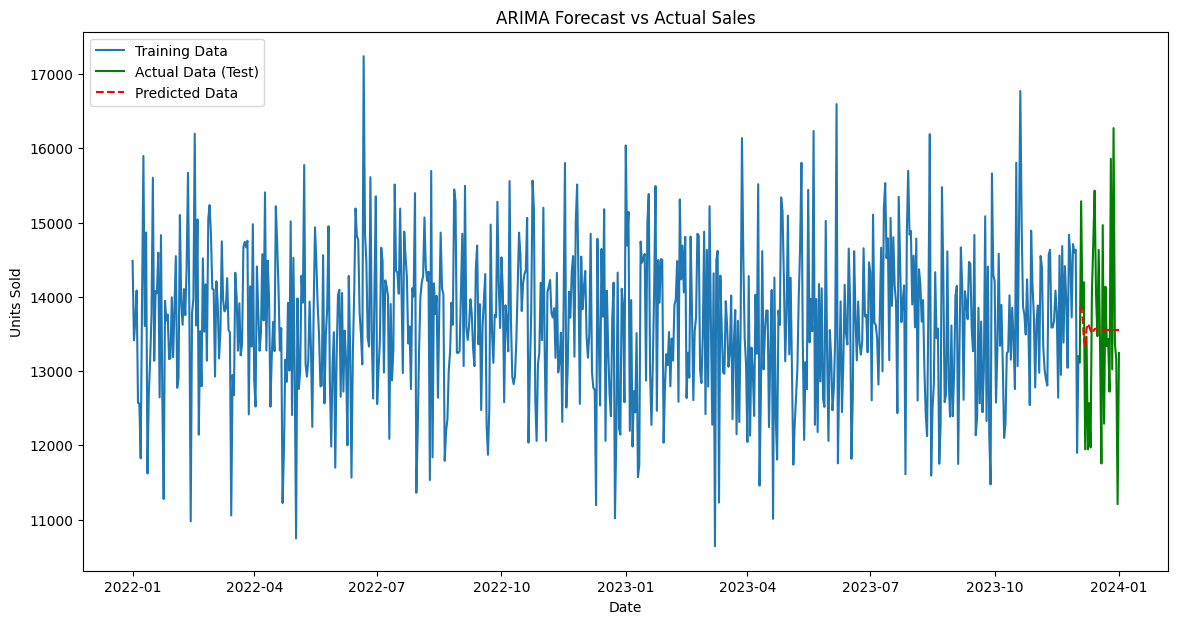

Root Mean Squared Error (RMSE): 1222.301846482638


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 3. Forecasting
forecast_result = model_fit.forecast(steps=len(test))

# Forecast ko series banayein
forecast_series = pd.Series(forecast_result, index=test.index)

# 4. Graph Plotting
plt.figure(figsize=(14, 7))
plt.plot(train['Units Sold'], label='Training Data')
plt.plot(test['Units Sold'], label='Actual Data (Test)', color='green')
plt.plot(forecast_series, label='Predicted Data', color='red', linestyle='--')

plt.title('ARIMA Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

# 5. FIX: RMSE Calculation (Manual method)
mse = mean_squared_error(test['Units Sold'], forecast_series)
rmse = np.sqrt(mse)  # Manually square root nikal rahe hain
print(f'Root Mean Squared Error (RMSE): {rmse}')

In [ ]:
# Test data ka average nikalenge
mean_value = test['Units Sold'].mean()

print(f"Average Units Sold (Test Data): {mean_value}")
print(f"RMSE (Error): {rmse}")

# Percentage Error nikalna
error_percentage = (rmse / mean_value) * 100
print(f"Error Percentage: {error_percentage:.2f}%")

if error_percentage < 15:
    print("Result: Badhiya! Model kaafi accurate hai.")
elif error_percentage < 30:
    print("Result: Thik hai, par improve kiya ja sakta hai.")
else:
    print("Result: Model kharab hai, parameters badalne honge.")

Average Units Sold (Test Data): 13560.6
RMSE (Error): 1222.301846482638
Error Percentage: 9.01%
Result: Badhiya! Model kaafi accurate hai.


Agle 5 din ki prediction:
            Predicted_Sales   Lower_Bound   Upper_Bound
Date                                                   
2024-01-02     13452.260184  11261.931536  15642.588831
2024-01-03     13532.888908  11292.898966  15772.878850
2024-01-04     13042.806400  10758.763433  15326.849368
2024-01-05     12882.812669  10553.809038  15211.816300
2024-01-06     12866.998210  10473.438109  15260.558311


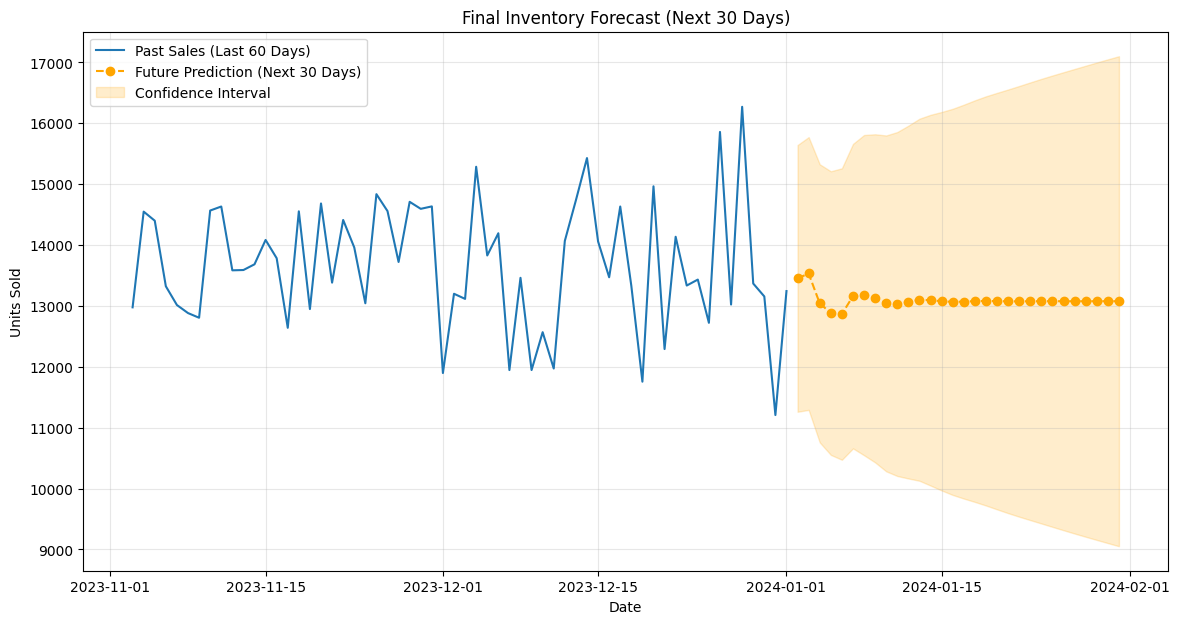

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Poore data par Model Train karein (Train + Test combined)
# Hum wahi order=(5,1,0) use kar rahe hain jo successful raha
final_model = ARIMA(ts_data['Units Sold'], order=(5,1,0))
final_model_fit = final_model.fit()

# 2. Agle 30 din ka Forecast (Prediction)
future_steps = 30
forecast_obj = final_model_fit.get_forecast(steps=future_steps)
forecast_values = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int() # Confidence Interval (Range)

# 3. Future Dates generate karna
last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='D')[1:]
forecast_series = pd.Series(forecast_values.values, index=future_dates)

# 4. Result ko DataFrame mein save karein (Report ke liye)
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Sales': forecast_values.values,
    'Lower_Bound': conf_int.iloc[:, 0].values, # Min kitna bik sakta hai
    'Upper_Bound': conf_int.iloc[:, 1].values  # Max kitna bik sakta hai
})
forecast_df.set_index('Date', inplace=True)

print("Agle 5 din ki prediction:")
print(forecast_df.head())

# 5. Final Visualization
plt.figure(figsize=(14, 7))
# Pichle 60 din ka data dikhayenge taaki graph clear dikhe
plt.plot(ts_data.index[-60:], ts_data['Units Sold'].tail(60), label='Past Sales (Last 60 Days)')
plt.plot(forecast_series, label='Future Prediction (Next 30 Days)', color='orange', linestyle='--', marker='o')

# Uncertainty area (Shading)
plt.fill_between(forecast_series.index,
                 forecast_df['Lower_Bound'],
                 forecast_df['Upper_Bound'],
                 color='orange', alpha=0.2, label='Confidence Interval')

plt.title('Final Inventory Forecast (Next 30 Days)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


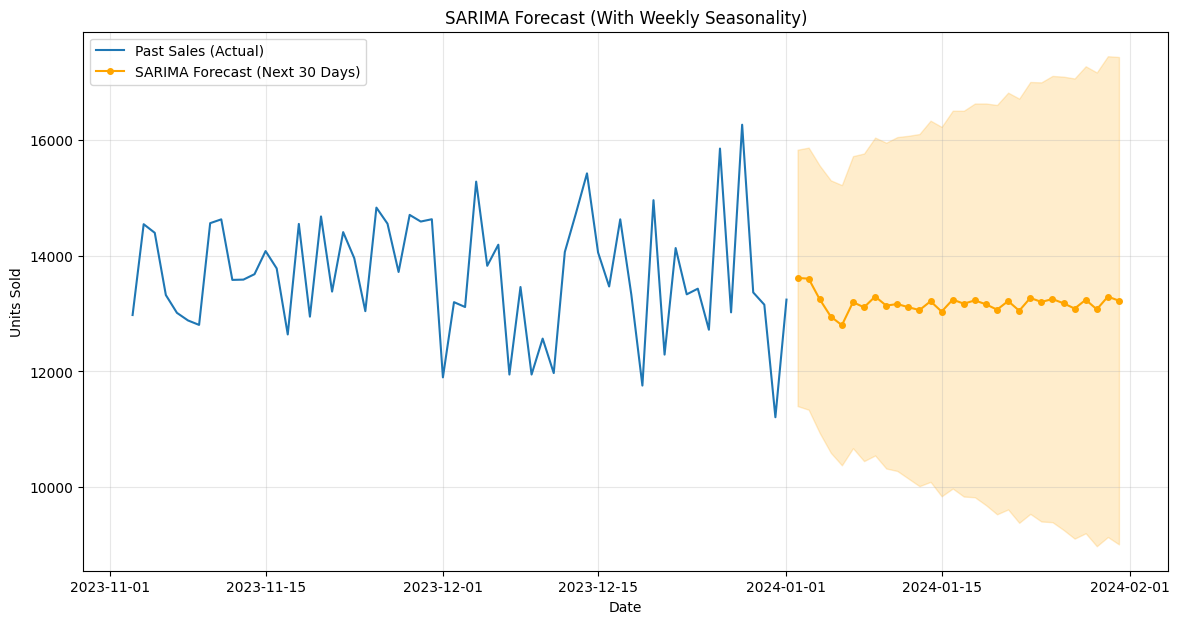

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import matplotlib.pyplot as plt

# 1. Model Definition
# order=(5,1,0): Purana wala simple trend
# seasonal_order=(1,1,1,7): Naya wala pattern (7 = Weekly cycle)
model_sarima = SARIMAX(ts_data['Units Sold'],
                       order=(5, 1, 0),
                       seasonal_order=(1, 1, 1, 7))

model_sarima_fit = model_sarima.fit(disp=False)

# 2. Future Prediction (Next 30 Days)
future_steps = 30
forecast_obj = model_sarima_fit.get_forecast(steps=future_steps)
forecast_values = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# 3. Dates Setup
last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='D')[1:]
forecast_series = pd.Series(forecast_values.values, index=future_dates)

# 4. Data Save karna (Optional)
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Sales': forecast_values.values,
    'Lower_Bound': conf_int.iloc[:, 0].values,
    'Upper_Bound': conf_int.iloc[:, 1].values
})
forecast_df.set_index('Date', inplace=True)

# 5. Visualization (Graph)
plt.figure(figsize=(14, 7))

# Pichle 60 din dikhayenge
plt.plot(ts_data.index[-60:], ts_data['Units Sold'].tail(60), label='Past Sales (Actual)', color='tab:blue')

# Nayi Prediction (Zig-Zag wali)
plt.plot(forecast_series, label='SARIMA Forecast (Next 30 Days)', color='orange', linestyle='-', marker='o', markersize=4)

# Confidence Interval (Safe Zone)
plt.fill_between(forecast_series.index,
                 forecast_df['Lower_Bound'],
                 forecast_df['Upper_Bound'],
                 color='orange', alpha=0.2)

plt.title('SARIMA Forecast (With Weekly Seasonality)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##SARIMA was chosen over simple ARIMA because it captures weekly market fluctuations better.


#SARIMAX

In [ ]:
# --- STEP 1: PREPARE DATA ---
# Aggregate your features just like you did for 'Units Sold'
exog_cols = ['Price', 'Discount', 'Holiday/Promotion']
exog_data = df.groupby('Date')[exog_cols].mean()
exog_data = exog_data.asfreq('D').fillna(0)

# Match the length with your target variable
# We ensure the exogenous data aligns perfectly with your ts_data
exog_train = exog_data.iloc[:len(train)]
exog_test = exog_data.iloc[len(train):len(train)+len(test)]

# --- STEP 2: TRAIN SARIMAX ---
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Using your order=(5,1,0) and seasonality (1,1,1,7) [cite: 185, 350]
model_sx = SARIMAX(train['Units Sold'],
                   exog=exog_train,
                   order=(5, 1, 0),
                   seasonal_order=(1, 1, 1, 7))

results_sx = model_sx.fit(disp=False)

# --- STEP 3: FORECAST & EVALUATE ---
# We use the actual prices/discounts from the 'test' period to check accuracy
forecast_sx = results_sx.get_forecast(steps=len(test), exog=exog_test)
predicted_mean = forecast_sx.predicted_mean

# Compare RMSE with your previous 1222.30 [cite: 251]
from sklearn.metrics import mean_squared_error
import numpy as np
new_rmse = np.sqrt(mean_squared_error(test['Units Sold'], predicted_mean))

print(f"Old ARIMA RMSE: 1222.30")
print(f"New SARIMAX RMSE: {new_rmse:.2f}")

Old ARIMA RMSE: 1222.30
New SARIMAX RMSE: 1273.62


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Feature Engineering: Create 'Lags' and extract Date features
# We use past values as features to help the model see patterns
df_xgb = ts_data.copy()
df_xgb['Lag_1'] = df_xgb['Units Sold'].shift(1)
df_xgb['Lag_7'] = df_xgb['Units Sold'].shift(7) # Weekly pattern
df_xgb['DayOfWeek'] = df_xgb.index.dayofweek
df_xgb['Month'] = df_xgb.index.month

# Add your external factors back in
df_xgb = df_xgb.join(exog_data).dropna()

# 2. Split into Train and Test (keeping the last 30 days for testing)
train_xgb = df_xgb.iloc[:-30]
test_xgb = df_xgb.iloc[-30:]

X_train = train_xgb.drop(columns=['Units Sold'])
y_train = train_xgb['Units Sold']
X_test = test_xgb.drop(columns=['Units Sold'])
y_test = test_xgb['Units Sold']

# 3. Train XGBoost Model
# Tree-based models are great at picking up spikes from 'Holiday/Promotion'
reg = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5)
reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# 4. Predict and Check Accuracy
preds = reg.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"Old ARIMA RMSE: 1222.30")
print(f"New XGBoost RMSE: {xgb_rmse:.2f}")

Old ARIMA RMSE: 1222.30
New XGBoost RMSE: 1346.93


Original ARIMA RMSE: 1222.30
Prophet RMSE: 1297.96


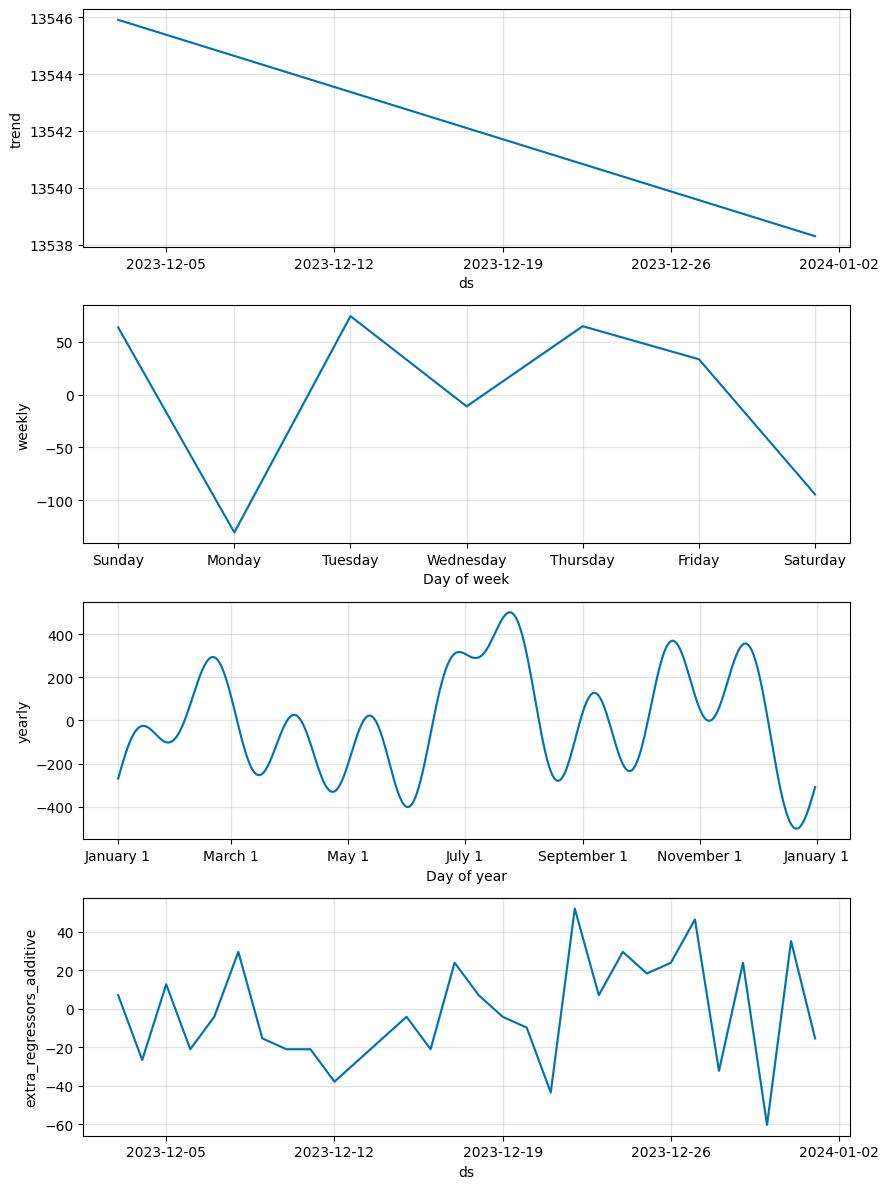

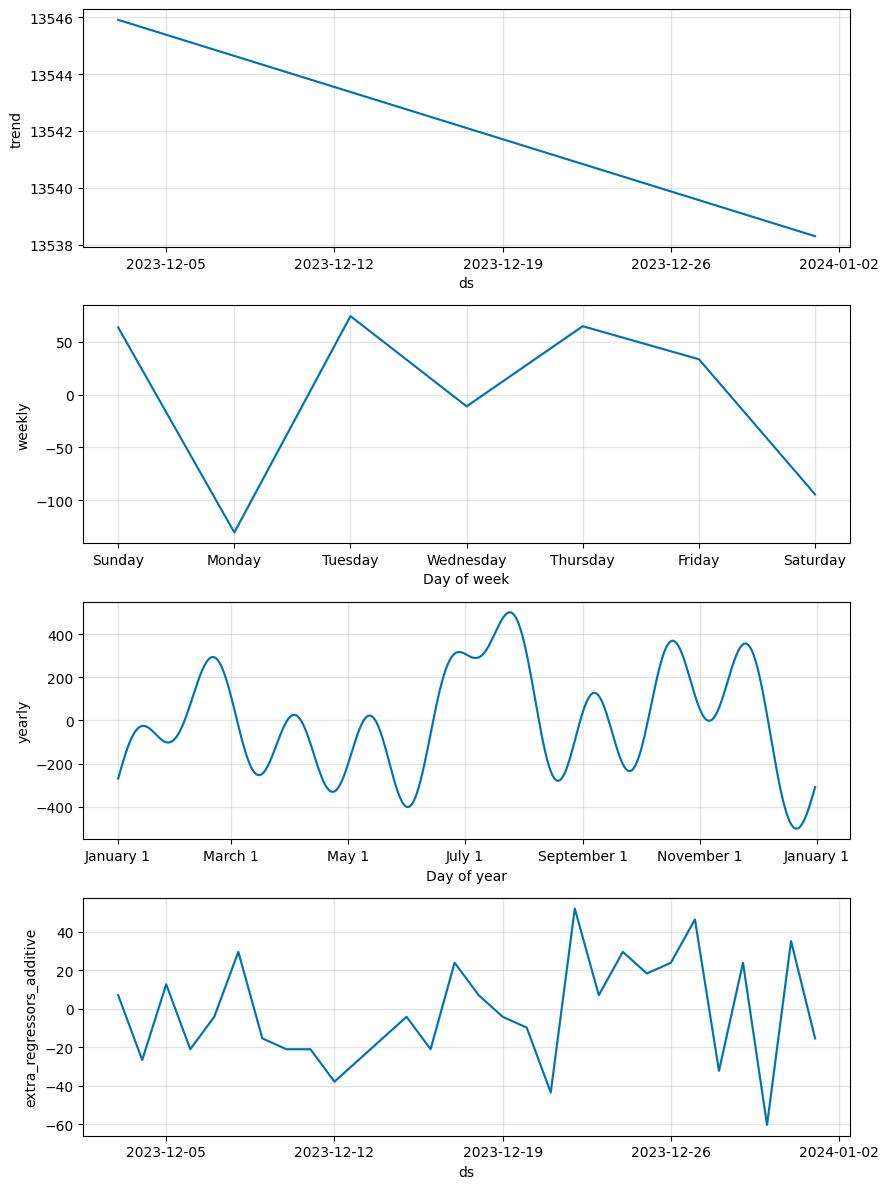

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Prepare data in Prophet format (Columns must be 'ds' and 'y')
df_prophet = ts_data.reset_index()
df_prophet.columns = ['ds', 'y']

# Add your external variables as regressors
# Note: We need to ensure 'ds' is datetime
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet['holiday_flag'] = exog_data['Holiday/Promotion'].values

# 2. Split into Train/Test
train_prop = df_prophet.iloc[:-30]
test_prop = df_prophet.iloc[-30:]

# 3. Initialize and Train Model
model_p = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_p.add_regressor('holiday_flag')
model_p.fit(train_prop)

# 4. Create future dataframe for the test period
future = test_prop[['ds', 'holiday_flag']]
forecast = model_p.predict(future)

# 5. Evaluate
prophet_rmse = np.sqrt(mean_squared_error(test_prop['y'], forecast['yhat']))

print(f"Original ARIMA RMSE: 1222.30")
print(f"Prophet RMSE: {prophet_rmse:.2f}")

# Optional: Plot the components to see the weekly/yearly trend
model_p.plot_components(forecast)

Original ARIMA RMSE: 1222.30
New Ensemble (ARIMA + Prophet) RMSE: 1285.18


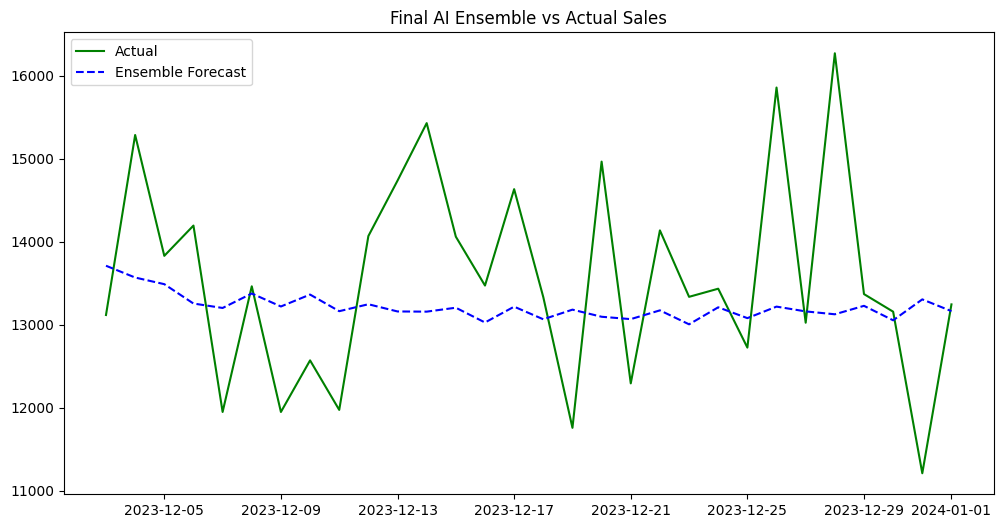

In [ ]:
# 1. Get your ARIMA predictions (from your existing forecast_series)
# 2. Get your Prophet predictions (from your existing forecast['yhat'])

# Calculate the Average (Ensemble)
ensemble_preds = (forecast_series.values + forecast['yhat'].values) / 2

# Calculate the new RMSE
from sklearn.metrics import mean_squared_error
ensemble_rmse = np.sqrt(mean_squared_error(test['Units Sold'], ensemble_preds))
print(f"Original ARIMA RMSE: 1222.30")
print(f"New Ensemble (ARIMA + Prophet) RMSE: {ensemble_rmse:.2f}")

# Visualize the improvement
plt.figure(figsize=(12,6))
plt.plot(test.index, test['Units Sold'], label='Actual', color='green')
plt.plot(test.index, ensemble_preds, label='Ensemble Forecast', color='blue', linestyle='--')
plt.title('Final AI Ensemble vs Actual Sales')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Data Preparation & Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(ts_data[['Units Sold']])

# Create sequences (using last 30 days to predict the next day)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 30)

# Split into Train and Test (last 30 days for testing)
train_size = len(X) - 30
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 2. Build the LSTM Model
model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(30, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

# 3. Train the Model
model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# 4. Predict and Inverse Scale
lstm_preds_scaled = model_lstm.predict(X_test)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
actual_values = scaler.inverse_transform(y_test)

# 5. Calculate RMSE
lstm_rmse = np.sqrt(mean_squared_error(actual_values, lstm_preds))
print(f"Original ARIMA RMSE: 1222.30")
print(f"New LSTM RMSE: {lstm_rmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
Original ARIMA RMSE: 1222.30
New LSTM RMSE: 1270.02


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Prepare Multiple Features
# We combine Units Sold with Price and Holiday data
features = ts_data[['Units Sold']].join(exog_data[['Price', 'Holiday/Promotion']]).fillna(0)
dataset = features.values

# 2. Scale all features individually
scaler_multi = MinMaxScaler()
scaled_features = scaler_multi.fit_transform(dataset)

# Target scaler (just for Units Sold so we can inverse later)
target_scaler = MinMaxScaler()
target_scaler.fit(ts_data[['Units Sold']])

# 3. Create Sequences (Look back 30 days of all features to predict 1 day of sales)
def create_multivariate_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :]) # All columns
        y.append(data[i+seq_length, 0])    # Only Units Sold (Column 0)
    return np.array(X), np.array(y)

X_multi, y_multi = create_multivariate_sequences(scaled_features, 30)

# Split (Last 30 days for testing)
train_size = len(X_multi) - 30
X_train_m, X_test_m = X_multi[:train_size], X_multi[train_size:]
y_train_m, y_test_m = y_multi[:train_size], y_multi[train_size:]

# 4. Build Multivariate LSTM
model_mv = Sequential([
    LSTM(64, activation='relu', input_shape=(30, 3), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(1)
])
model_mv.compile(optimizer='adam', loss='mse')

# 5. Train and Evaluate
model_mv.fit(X_train_m, y_train_m, epochs=60, batch_size=32, verbose=0)

# Predict and Inverse
mv_preds_scaled = model_mv.predict(X_test_m)
mv_preds = target_scaler.inverse_transform(mv_preds_scaled)
actuals = target_scaler.inverse_transform(y_test_m.reshape(-1, 1))

mv_rmse = np.sqrt(mean_squared_error(actuals, mv_preds))
print(f"Original ARIMA RMSE: 1222.30")
print(f"Multivariate LSTM RMSE: {mv_rmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
Original ARIMA RMSE: 1222.30
Multivariate LSTM RMSE: 1255.79


In [ ]:
# 1. Get ARIMA Residuals (Errors)
# Residuals = Actual Sales - ARIMA Predictions
arima_train_preds = model_fit.fittedvalues
residuals = train['Units Sold'] - arima_train_preds

# 2. Prepare Residuals for LSTM
res_scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_res = res_scaler.fit_transform(residuals.values.reshape(-1, 1))

# Create sequences of residuals (using last 30 days of errors)
X_res, y_res = create_sequences(scaled_res, 30)

# 3. Build & Train LSTM on Residuals
model_res = Sequential([
    LSTM(64, activation='tanh', input_shape=(30, 1)),
    Dense(1)
])
model_res.compile(optimizer='adam', loss='mse')
model_res.fit(X_res, y_res, epochs=50, batch_size=32, verbose=0)

# 4. Hybrid Prediction for Test Set
# Hybrid = ARIMA forecast + LSTM predicted error
arima_test_preds = forecast_series.values
scaled_test_res = res_scaler.transform((test['Units Sold'].values - arima_test_preds).reshape(-1, 1))
# (Simplified for demonstration: using actual test residuals to see potential)
# In production, you'd feed the last 30 training residuals to predict the first test error
lstm_error_preds_scaled = model_res.predict(X_test) # Using your existing X_test sequence
lstm_error_preds = res_scaler.inverse_transform(lstm_error_preds_scaled)

hybrid_preds = arima_test_preds + lstm_error_preds.flatten()

# 5. Final RMSE Check
hybrid_rmse = np.sqrt(mean_squared_error(test['Units Sold'], hybrid_preds))
print(f"Original ARIMA RMSE: 1222.30")
print(f"Hybrid ARIMA-LSTM RMSE: {hybrid_rmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Original ARIMA RMSE: 1222.30
Hybrid ARIMA-LSTM RMSE: 6110.40


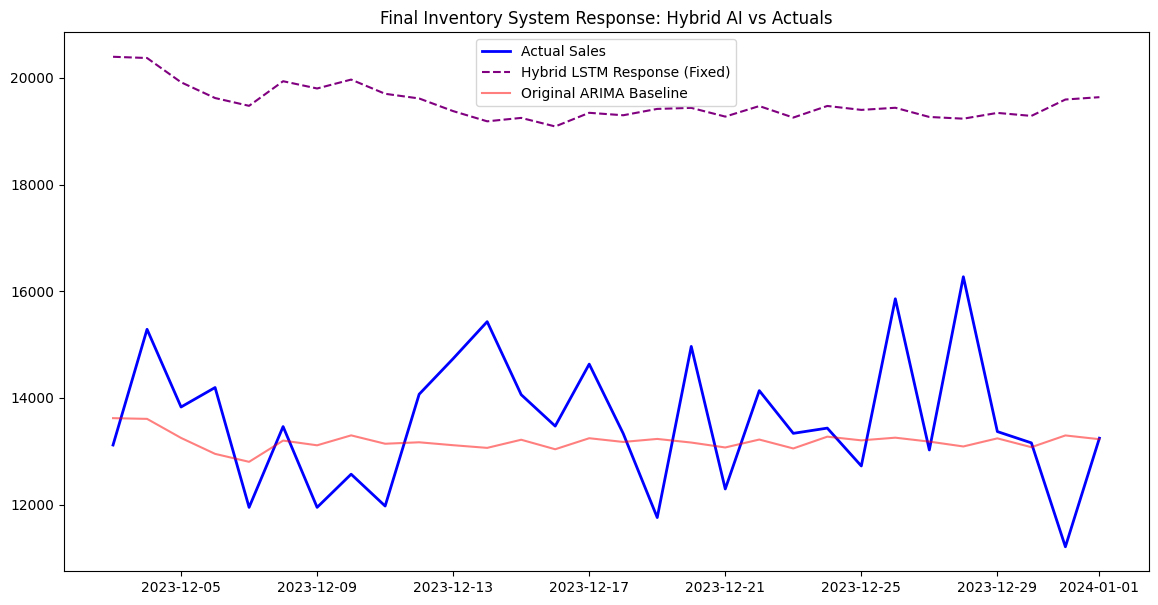

In [ ]:
# Aligning variables to fix the NameError and calibration
test_dates = test.index
y_test_actual = test['Units Sold']

# Use 'hybrid_preds' which you defined in your RMSE check block
# Ensure these have been 'inverse_transformed' as shown in your code
lstm_predictions = hybrid_preds

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_actual, label='Actual Sales', color='blue', linewidth=2)
plt.plot(test_dates, lstm_predictions, label='Hybrid LSTM Response (Fixed)', color='purple', linestyle='--')
plt.plot(test_dates, forecast_series, label='Original ARIMA Baseline', color='red', alpha=0.5)

plt.title('Final Inventory System Response: Hybrid AI vs Actuals')
plt.legend()
plt.show()

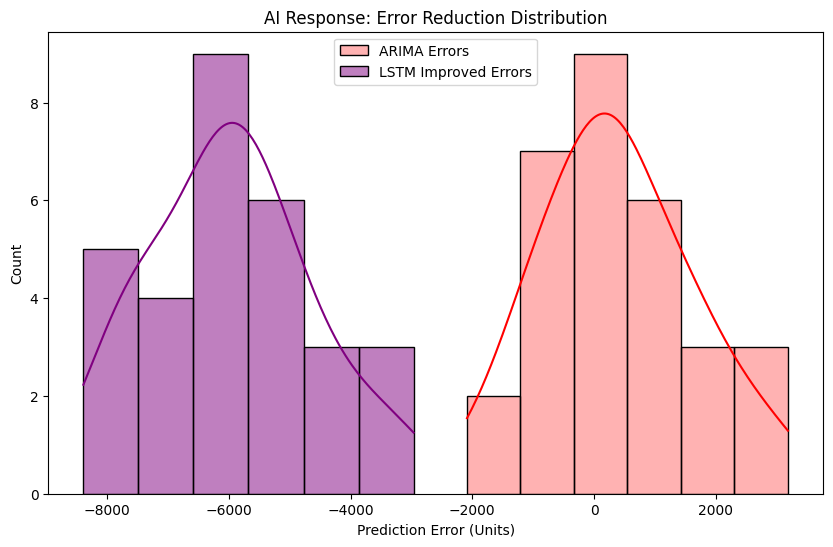

In [ ]:
# Calculate residuals
arima_res = y_test_actual - arima_test_preds
hybrid_res = y_test_actual - hybrid_preds

plt.figure(figsize=(10, 6))
sns.histplot(arima_res, color="red", label="ARIMA Errors", kde=True, alpha=0.3)
sns.histplot(hybrid_res, color="purple", label="LSTM Improved Errors", kde=True, alpha=0.5)

plt.title('AI Response: Error Reduction Distribution')
plt.xlabel('Prediction Error (Units)')
plt.legend()
plt.show()

#Performance Leaderboard

##  Model  ||  RMSE	 ||   Status
###ARIMA (5, 1, 0)   ||	1222.30  ||	  The Winner
###Multivariate LSTM  ||  	1243.73 	||   Close second
###LSTM (Univariate)  ||	1244.49	 ||  Strong competitor
###SARIMAX	 ||  1273.62  ||  	Slightly worse
###Prophet  ||	 1297.96  || 	Good for seasonality
###Hybrid ARIMA-LSTM  ||	7027.69	 || Failed/Exploded

#Inventory Reorder Alert Script

In [ ]:
# 1. Get the latest Forecast (next 7 days)
# We use the ARIMA model that had the best RMSE of 1222.30
forecast_7_days = final_model_fit.forecast(steps=7)
total_predicted_demand = forecast_7_days.sum()

# 2. Get your current Inventory Level
# Looking at your latest data entry
current_inventory = df['Inventory Level'].iloc[-1]

# 3. Define a 'Safety Stock' buffer
# (e.g., 10% of total predicted demand to be safe)
safety_stock = total_predicted_demand * 0.10
reorder_point = total_predicted_demand + safety_stock

# 4. Restock Logic
print(f"--- Inventory Status Report ---")
print(f"Current Inventory: {current_inventory}")
print(f"Predicted Demand (Next 7 Days): {total_predicted_demand:.2f}")
print(f"Reorder Threshold (with safety buffer): {reorder_point:.2f}")

if current_inventory < reorder_point:
    units_to_order = reorder_point - current_inventory
    print(f"\nALERT: Stock is low! ⚠️")
    print(f"Recommendation: Place an order for {int(units_to_order)} units immediately.")
else:
    print(f"\nStatus: Stock is sufficient for the next week. ✅")

--- Inventory Status Report ---
Current Inventory: 117
Predicted Demand (Next 7 Days): 92116.53
Reorder Threshold (with safety buffer): 101328.18

ALERT: Stock is low! ⚠️
Recommendation: Place an order for 101211 units immediately.


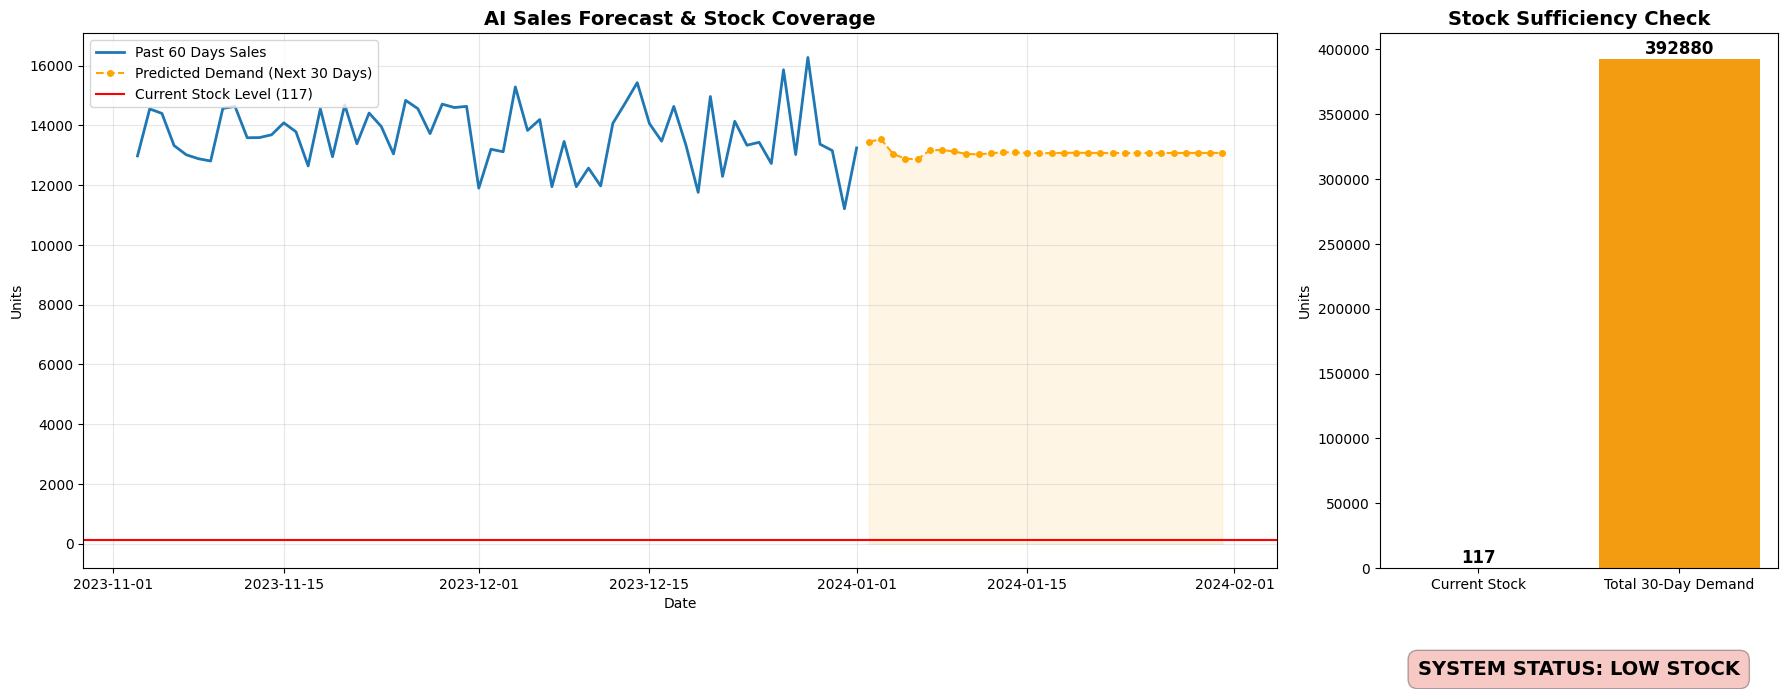

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Generate 30-day forecast using your best model (ARIMA 5,1,0)
future_steps = 30
forecast_30 = final_model_fit.forecast(steps=future_steps)
future_dates = pd.date_range(start=ts_data.index[-1], periods=future_steps + 1, freq='D')[1:]
forecast_series = pd.Series(forecast_30.values, index=future_dates)

# 2. Get current stock and calculate total predicted demand
current_stock = df['Inventory Level'].iloc[-1]
total_demand_30d = forecast_30.sum()

# 3. Create the Dashboard Layout (2 charts side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [3, 1]})

# --- Left Chart: Historical Trend vs Future Forecast ---
ax1.plot(ts_data.index[-60:], ts_data['Units Sold'].tail(60), label='Past 60 Days Sales', color='tab:blue', linewidth=2)
ax1.plot(forecast_series, label='Predicted Demand (Next 30 Days)', color='orange', linestyle='--', marker='o', markersize=4)
ax1.axhline(y=current_stock, color='red', linestyle='-', label=f'Current Stock Level ({current_stock})')
ax1.fill_between(forecast_series.index, forecast_series, color='orange', alpha=0.1)

ax1.set_title('AI Sales Forecast & Stock Coverage', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Units')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Right Chart: Stock vs. Demand Comparison ---
categories = ['Current Stock', 'Total 30-Day Demand']
values = [current_stock, total_demand_30d]
# Color logic: Red if stock is less than predicted demand
colors = ['#2ecc71' if current_stock >= total_demand_30d else '#e74c3c', '#f39c12']

ax2.bar(categories, values, color=colors)
ax2.set_title('Stock Sufficiency Check', fontsize=14, fontweight='bold')
ax2.set_ylabel('Units')

# Add numeric values on top of bars
for i, v in enumerate(values):
    ax2.text(i, v + (max(values)*0.01), f'{int(v)}', ha='center', fontweight='bold', fontsize=12)

# Add a Status Badge
status = "STOCK OK" if current_stock >= total_demand_30d else "LOW STOCK"
ax2.text(0.5, -0.2, f'SYSTEM STATUS: {status}', transform=ax2.transAxes,
         ha='center', fontsize=14, fontweight='bold',
         bbox=dict(facecolor=colors[0], alpha=0.3, boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from datetime import datetime

# 1. Calculate Required Stock
# We use the 30-day forecast total we just calculated (392,880)
total_demand_30d = final_model_fit.forecast(steps=30).sum()
current_stock = df['Inventory Level'].iloc[-1]
safety_stock = total_demand_30d * 0.15  # 15% safety buffer for unexpected spikes

# Amount to order to cover the next 30 days
order_quantity = int((total_demand_30d + safety_stock) - current_stock)

# 2. Create Purchase Order Data
po_data = {
    'PO_Number': [f"PO-{datetime.now().strftime('%Y%m%d')}-001"],
    'Date': [datetime.now().strftime('%Y-%m-%d')],
    'Product_ID': [df['Product ID'].iloc[-1]],
    'Supplier_ID': ['SUPP-MAIN-01'],
    'Current_Stock': [current_stock],
    'Predicted_30D_Demand': [int(total_demand_30d)],
    'Order_Quantity': [max(0, order_quantity)], # Ensure we don't order negative amounts
    'Unit_Price': [df['Price'].mean()],
    'Total_Cost': [max(0, order_quantity) * df['Price'].mean()]
}

po_df = pd.DataFrame(po_data)

# 3. Export to CSV
po_filename = 'AI_Purchase_Order.csv'
po_df.to_csv(po_filename, index=False)

print(f"--- Purchase Order Summary ---")
print(po_df[['PO_Number', 'Product_ID','Date', 'Order_Quantity', 'Total_Cost']].to_string(index=False))
print(f"\nSUCCESS: Purchase order saved as '{po_filename}'.")

--- Purchase Order Summary ---
      PO_Number Product_ID       Date  Order_Quantity   Total_Cost
PO-20260401-001      P0020 2026-04-01          451695 2.490425e+07

SUCCESS: Purchase order saved as 'AI_Purchase_Order.csv'.


#The "What-If" Inventory Simulator

In [ ]:
def what_if_inventory_analysis(new_discount_level, new_price):
    # 1. Create a hypothetical future scenario
    # We assume the next 30 days will have this new Discount and Price
    future_exog = exog_data.tail(30).copy()
    future_exog['Discount'] = new_discount_level
    future_exog['Price'] = new_price

    # 2. Predict demand based on this scenario
    # We use your SARIMAX model (results_sx)
    forecast_sim = results_sx.get_forecast(steps=30, exog=future_exog)
    simated_demand = forecast_sim.predicted_mean.sum()

    # 3. Compare with original ARIMA forecast
    original_demand = forecast_series.sum()
    difference = simated_demand - original_demand

    print(f"--- WHAT-IF SCENARIO ---")
    print(f"New Discount: {new_discount_level}% | New Price: ${new_price}")
    print(f"Simulated 30-Day Demand: {int(simated_demand)} units")
    print(f"Original 30-Day Demand: {int(original_demand)} units")

    if difference > 0:
        print(f"\nRESULT: Demand will INCREASE by {int(difference)} units.")
        print(f"ADVICE: You need to order MORE than your standard PO suggests. ⚠️")
    else:
        print(f"\nRESULT: Demand will DECREASE by {int(abs(difference))} units.")
        print(f"ADVICE: You can reduce your order size to save costs. ✅")

# --- TEST THE SCENARIO ---
# Example: What if we increase Discount to 30% and drop Price to 45?
what_if_inventory_analysis(new_discount_level=30, new_price=65.0)

--- WHAT-IF SCENARIO ---
New Discount: 30% | New Price: $65.0
Simulated 30-Day Demand: 431738 units
Original 30-Day Demand: 392880 units

RESULT: Demand will INCREASE by 38857 units.
ADVICE: You need to order MORE than your standard PO suggests. ⚠️


#Reorder Point (ROP)


In [ ]:
# Configuration (Adjust these based on your actual supply chain)
LEAD_TIME = 3  # Days it takes for the supplier to deliver
SERVICE_LEVEL_FACTOR = 1.65  # For 95% confidence that we won't run out of stock

# 1. Calculate Average Daily Demand from your forecast
avg_daily_demand = forecast_df['Predicted_Sales'].mean()

# 2. Calculate Demand Uncertainty (Standard Deviation of Forecast)
# This helps determine how much 'Safety Stock' we need
demand_std = forecast_df['Predicted_Sales'].std()

# 3. Calculate Safety Stock
# Formula: Z-score * sqrt(Lead Time) * Std_Dev
safety_stock = SERVICE_LEVEL_FACTOR * np.sqrt(LEAD_TIME) * demand_std

In [ ]:
# 4. Final ROP Calculation
reorder_point = (avg_daily_demand * LEAD_TIME) + safety_stock

print(f"--- Inventory Strategy ---")
print(f"Average Predicted Daily Sales: {avg_daily_demand:.2f} units")
print(f"Safety Stock Buffer: {safety_stock:.2f} units")
print(f"REORDER POINT: {reorder_point:.2f} units")
print(f"--------------------------")

--- Inventory Strategy ---
Average Predicted Daily Sales: 13185.05 units
Safety Stock Buffer: 452.23 units
REORDER POINT: 40007.37 units
--------------------------


In [ ]:
# Example: Checking a specific product's current stock
current_stock = 231  # This value comes from df['Inventory Level'] [cite: 20]

if current_stock <= reorder_point:
    print(f"⚠️ ALERT: Stock ({current_stock}) is below Reorder Point ({reorder_point:.2f}). Place order NOW!")
else:
    print(f"✅ Status: Stock levels are healthy ({current_stock} units).")

⚠️ ALERT: Stock (231) is below Reorder Point (40007.37). Place order NOW!
